This notebook describes how to plot diagnostic plot, including a spectrum, expected observed line wavelengthes, cross-correlation signals, and best-fit Gaussian, and handle other parameters

First measure a redshift of a spectrum
For redshft measurement, refer to z_measurement.ipynb

In [4]:
from RVSNUpy.spectrum_import import sdss_fits
sdss_spec = sdss_fits('spectra/sdss_spec1.fits')

from RVSNUpy.template import sdss_galaxy_templates
gal_temps = sdss_galaxy_templates("vacuum")

from RVSNUpy.template import zp_calib
gal_temps = zp_calib(gal_temps)

from RVSNUpy.rvm import rvm
measure = rvm(gal_temps)

measure.z_single(sdss_spec)

,template_name,z,zerr,r,chi_eff,note
0,Late_type_galaxy,0.167850,0.000070,15.120880,1.161129,
1,Early_type_galaxy,0.168093,0.000066,9.514006,1.269936,
2,Luminous_red_galaxy,0.168122,0.000068,9.204870,1.152073,best


Dianostic plot can be plotted for each template.
The diagnostic plot incldue a spectrum (with small S/N era at sides being trimed), expected observed line wavelengths, cross-correlation signals, and effective chi square.

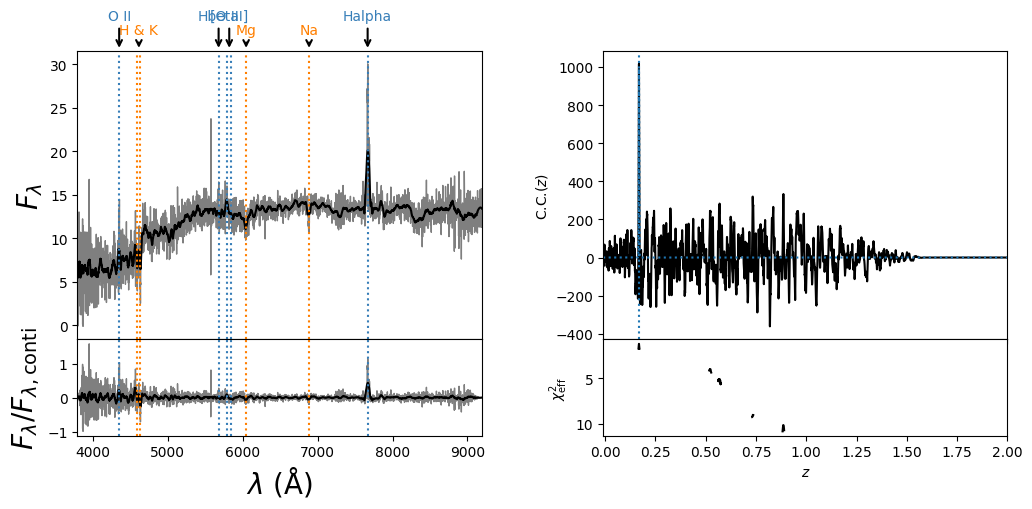

In [7]:
# Specify a template
template_result = measure.cc_result['Early_type_galaxy']

fig, (ax00, ax01, ax10, ax11) = template_result.diagnostic_plot()

The left panel shows an input and normalized spectrum. The grey lines indicate original (not smoothed) spectra and black lines indicate smoothed ones.

The top right panel shows the cross-correlation signal as a funtion of the template's redshift. The blue dotted lines indicate the best-fit Gaussian and its center.

The bottom right pnael shows the effective chi square as a function of the template's redshift. Note that, only values near the peaks are plotted because the chi suare compuations are only perfomred near the peaks.

The function returns, fig, and (ax00, ax01, ax10, ax11). Here, fig is the variable for the figure, and ax00, ax01, ax10, ax11 are the axes variable for top left, top right, bottom left, bottom right. You can save the figure or rescale the panel withi these variables.

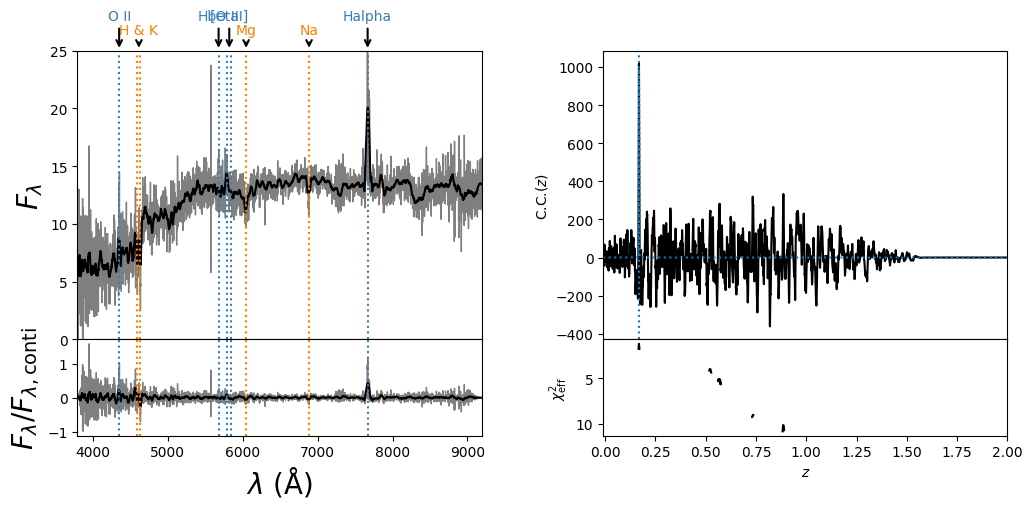

In [10]:
# e.g.)
fig, (ax00, ax01, ax10, ax11) = template_result.diagnostic_plot()
ax00.set_ylim(0,25)
fig.savefig('diagnostic_plot.pdf')


diagnostic_plot() takes the followings as inputs

scale00=None, scale10=None, scale01=None, scale11=None,
                    abs_lines = {'H & K': [3934.777, 3969.588], 'Mg': 5176.7, 'Na': 5895.6},
                    em_lines = {'Mg II': 2799.117, 'O II': 3727.092,
                                'Hbeta': 4862.68, '[O III]': [4960.295,5008.240],'Halpha': 6564.61},
                    plot_abs_lines=True, plot_em_lines=True

- scale00 (str, default=None): If 'smooth', ylim of the top left panel is scaled to the smoothed spectrum. If Noen, it is scaled to the original spectrum
- scale10 (str, default=None): If 'smooth', ylim of the bottom left panel is scaled to the smoothed spectrum. If None, it is scaled to the original spectrum
- scale10 (str, default=None): If 'peak', xlim of the top right panel is scaled to the best-fit Gaussian. If None, it is scaled to the entire x-range.
- scale11 (str, default=None): If 'peak', xlim of the top right panel is scaled to the best-fit Gaussian. If None, it is scaled to the entire x-range.
- abs_lines (dict, default= {'H & K': [3934.777, 3969.588], 'Mg': 5176.7, 'Na': 5895.6}): The list of absorption lines and their names to be plotted. The lines in the same list are simulatenously marked with the corresponding name. e.g.) 'H & K': [3934.777, 3969.588]
- em _lines (dict, default={'Mg II': 2799.117, 'O II': 3727.092,
                                'Hbeta': 4862.68, '[O III]': [4960.295,5008.240],'Halpha': 6564.61}): The list of emission lines and their names to be plotted. The lines in the same list are simulatenously marked with the corresponding name. e.g.) '[O III]': [4960.295,5008.240]
- plot_abs_lines (boolen, default=True): If true, plot the absorption lines
- plot_em_lines (boolen, default=True): If true, plot the emission lines